# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

Jonathan Jalbert<br/>
Professeur agrégé au Département de mathématiques et de génie industriel<br/>
Polytechnique Montréal<br/>


# TD4 - Régression linéaire

Ce TD concerne la régression linéaire (Chapitre 2 du cours). À la fin de ce TD, vous devriez être avoir été en mesure de :
- Choisir un modèle sur la base de l'estimation ou de la prédiction.
- Vérifier pour la présence de multicolinéarité.
- Transformer les variables pour modéliser des relations non-linéaires.


## Contexte : Poids des poissons

Le fichier *fishweights.csv* contient les caractéristiques de 158 poissons péchés dans le lac Laengelmavesi en Finlande. Nous étudierons le poids (Weight en grammes) des poissons en fonction de variables explicatives suivantes :
- l'espèce de poisson (species) ;
- la longueur standard (StandardLength) ;
- la longeur non standard  (NonStandardLength) ;
- la longueur totale (TotalLength) ;
- la hauteur (Height) ;
- la largeur (Width).

          ___/////___                  _
         /           \    ___          |
       /\             \_ /  /          H
     <   )            __)  \           |
       \/_\\_________/   \__\          _

     |------- SL -------|
     |------- NSL ---------|
     |------- TL ------------|

In [37]:
using CSV 
using DataFrames
using Distributions
using Gadfly
using LinearAlgebra
using Statistics

## Chargement des données

In [38]:
data = CSV.read("fishweights.csv", DataFrame)
first(data,10)

Row,Species,Weight,StandardLength,NonStandardLength,TotalLength,Height,Width
,String15,Float64,Float64,Float64,Float64,Float64,Float64
1,Brème,242.0,23.2,25.4,30.0,11.5,4.0
2,Brème,290.0,24.0,26.3,31.2,12.5,4.3
3,Brème,340.0,23.9,26.5,31.1,12.4,4.7
4,Brème,363.0,26.3,29.0,33.5,12.7,4.5
5,Brème,430.0,26.5,29.0,34.0,12.4,5.1
6,Brème,450.0,26.8,29.7,34.7,13.6,4.9
7,Brème,500.0,26.8,29.7,34.5,14.2,5.3
8,Brème,390.0,27.6,30.0,35.0,12.7,4.7
9,Brème,450.0,27.6,30.0,35.1,14.0,4.8


# Exercice 1 - Analyse exploratoire

## a) Illustrez les poids en fonction des espèces de poisson

**Note :** Avec Gadfly, la variable *x* peut être une variable catégorielle.

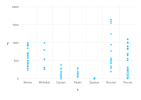

In [39]:
# illustrate weight with species in julia and gadfly using layers

p = plot(x=data.Species, y=data.Weight, Geom.point)
p


## b) Illustrez les poids en fonction de la longeur standard et des espèces.

**Suggestion :** Utilisez l'option *color* de Gadfly pour distinguer les différentes espèces.

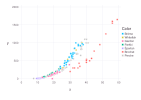

In [40]:
# weight vs StandardLength, colored by Species
p = plot(x=data.StandardLength, y=data.Weight, color=data.Species, Geom.point)

## c) Calculez le poids moyen pour chaque espèce ainsi que le nombre d'observations pour chaque espèce.

Les fonctions `combine()` et `groupby()` permettent d'effectuer rapidement ces tâches. Puisqu'elles ne sont pas intuitives, je vous donne d'emblée la réponse. C'est une combinaison de commandes qui pourra vous être utile dans tout le cours.

In [44]:
df = combine(groupby(data, :Species), :Weight => mean => :Weight, :Weight => length => :n)

Row,Species,Weight,n
,String15,Float64,Int64
1,Brème,626.0,34
2,Whitefish,531.0,6
3,Gardon,152.05,20
4,Parkki,154.818,11
5,Éperlan,11.1786,14
6,Brochet,718.706,17
7,Perche,382.239,56


# Exercice 2 - Ajustement *vs* prédiction

Dans cet excercice, on considère le **poids** des éperlans en fonction de la **longueur standard**. On utilisera un ensemble d'entraînement ainsi qu'un ensemble de validation pour évaluer l'erreur de prédiction sur des données non utilisées pour l'estimation des paramètres.

In [45]:
"""
    construct_structure(x::Vector{<:Real}, order::Int)

Construction de la matrice de structure du modèle polynomial d'ordre `order` à partir du vecteur `x`.
"""
function construct_structure(x::Vector{<:Real}, order::Int)
    
    X = Array{Float64}(undef, length(x), order+1)
    
    for p in 0:order
       X[:,p+1] = x.^p 
    end
    
    return X
    
end

construct_structure

## a) Construction de l'ensemble d'entraînement et de validation pour les éperlans

In [54]:
data_eperlan = filter(:Species => s -> s == "Éperlan", data)
entrainement = data_eperlan[1:2:(end-1), :]
validation = data_eperlan[2:2:end, :]

Row,Species,Weight,StandardLength,NonStandardLength,TotalLength,Height,Width
,String15,Float64,Float64,Float64,Float64,Float64,Float64
1,Éperlan,7.5,10.0,10.5,11.6,2.0,1.2
2,Éperlan,9.7,10.4,11.0,12.0,2.2,1.4
3,Éperlan,8.7,10.8,11.3,12.6,2.0,1.3
4,Éperlan,9.9,11.3,11.8,13.1,2.2,1.2
5,Éperlan,12.2,11.5,12.2,13.4,2.1,1.4
6,Éperlan,12.2,12.1,13.0,13.8,2.3,1.3
7,Éperlan,19.9,13.8,15.0,16.2,2.9,1.9


## b) Modèle linéaire

1. Estimez la droite de régression avec les données de l'ensemble d'entraînement.
2. Tracez la droite de régression ainsi que les points de l'ensemble d'entraînement.
3. Ajoutez les points de validation sur le graphique avec une autre couleur.

**Suggestion :** Utilisez la fonction `layer()` de Gadfly pour ajouter plusieurs couches à un graphique.

In [55]:
# 1. estimer droite de régression avec les données de l'entrainement
using GLM
model = lm(@formula(Weight ~ StandardLength), entrainement)


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Weight ~ 1 + StandardLength

Coefficients:
────────────────────────────────────────────────────────────────────────────
                    Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)     -26.5273     6.11325   -4.34    0.0074  -42.2419   -10.8127
StandardLength    3.37312    0.547798   6.16    0.0016    1.96496    4.78128
────────────────────────────────────────────────────────────────────────────

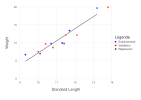

In [56]:
# 2. Tracer la droite de régression et les points d'entraînement
# 3. Ajouter les points de validation avec une autre couleur

# Créer des points pour la ligne de régression (triés par StandardLength)
x_sorted = sort(entrainement.StandardLength)
x_range = range(minimum(x_sorted), maximum(x_sorted), length=100)
y_pred = predict(model, DataFrame(StandardLength=x_range))

p = plot(
    layer(x=entrainement.StandardLength, y=entrainement.Weight, Geom.point, Theme(default_color="blue")),
    layer(x=validation.StandardLength, y=validation.Weight, Geom.point, Theme(default_color="red")),
    layer(x=x_range, y=y_pred, Geom.line, Theme(default_color="black")),
    Guide.xlabel("Standard Length"), 
    Guide.ylabel("Weight"),
    Guide.manual_color_key("Légende", ["Entraînement", "Validation", "Régression"], ["blue", "red", "black"])
)

## c) Modèle cubique

1. Estimez les paramètres du modèle cubique en utilisant les données de l'ensemble d'entraînement.
2. Tracez la courbe donnée par le modèle ainsi que les points de l'ensemble d'entraînement.
3. Ajoutez les points de validation sur le graphique avec une autre couleur.

**Suggestion :** Utilisez la fonction `construct_structure()` fournie pour construire la matrice de structure pour le modèle cubique avec `order=3`.

In [ ]:
# 1. Estimez les paramètres du modèle cubique en utilisant les données de l'ensemble d'entraînement. 

# Construire la matrice de structure pour le modèle cubique (ordre 3)
X_train = construct_structure(entrainement.StandardLength, 3)
y_train = entrainement.Weight

# Estimation des paramètres par moindres carrés
beta = X_train \ y_train

# Créer le modèle cubique
model_cubic = bet

4-element Vector{Float64}:
 162.50492980411406
 -39.681059289859334
   3.128695981627491
  -0.07135740073944273

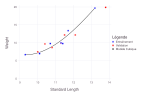

In [63]:
# 2. Tracez la courbe donnée par le modèle ainsi que les points de l'ensemble d'entraînement.
# 3. Ajoutez les points de validation sur le graphique avec une autre couleur.

# Créer des points pour la courbe cubique
x_range = range(minimum(entrainement.StandardLength), maximum(entrainement.StandardLength), length=100)
X_pred = construct_structure(collect(x_range), 3)
y_pred_cubic = X_pred * model_cubic

p_cubic = plot(
    layer(x=entrainement.StandardLength, y=entrainement.Weight, Geom.point, Theme(default_color="blue")),
    layer(x=validation.StandardLength, y=validation.Weight, Geom.point, Theme(default_color="red")),
    layer(x=x_range, y=y_pred_cubic, Geom.line, Theme(default_color="black")),
    Guide.xlabel("Standard Length"),
    Guide.ylabel("Weight"),
    Guide.manual_color_key("Légende", ["Entraînement", "Validation", "Modèle Cubique"], ["blue", "red", "black"])
)

## d) Modèle d'ordre 6

1. Estimez les paramètres du modèle d'ordre 6 en utilisant les données de l'ensemble d'entraînement.
2. Tracez la courbe donnée par le modèle ainsi que les points de l'ensemble d'entraînement.
3. Ajoutez les points de validation sur le graphique avec une autre couleur.

**Suggestion :** Utilisez la fonction `construct_structure()` fournie pour construire la matrice de structure pour le modèle cubique avec `order=6`.

In [64]:
# 1. Estimez les paramètres du modèle d'ordre 6 en utilisant les données de l'ensemble d'entraînement.

# Construire la matrice de structure pour le modèle d'ordre 6
X_train = construct_structure(entrainement.StandardLength, 6)
y_train = entrainement.Weight

# Estimation des paramètres par moindres carrés
beta = X_train \ y_train

# Créer le modèle d'ordre 6
model_order_6 = beta

7-element Vector{Float64}:
     -1.069699042625637e7
      5.9105394553339705e6
     -1.3574791049096948e6
 165873.7642156755
 -11372.870525494158
    414.829385620383
     -6.288482906477937

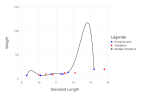

In [65]:
# 2. Tracez la courbe donnée par le modèle ainsi que les points de l'ensemble d'entraînement.

# Créer des points pour la courbe d'ordre 6
x_range = range(minimum(entrainement.StandardLength), maximum(entrainement.StandardLength), length=100)
X_pred = construct_structure(collect(x_range), 6)
y_pred_order_6 = X_pred * model_order_6

p_order_6 = plot(
    layer(x=entrainement.StandardLength, y=entrainement.Weight, Geom.point, Theme(default_color="blue")),
    layer(x=validation.StandardLength, y=validation.Weight, Geom.point, Theme(default_color="red")),
    layer(x=x_range, y=y_pred_order_6, Geom.line, Theme(default_color="black")),
    Guide.xlabel("Standard Length"),
    Guide.ylabel("Weight"),
    Guide.manual_color_key("Légende", ["Entraînement", "Validation", "Modèle d'Ordre 6"], ["blue", "red", "black"])
)


## e) Calcul de la qualité d'ajustement et de l'erreur de prédiction

Pour les modèles d'ordre 0 à 6, calculez 
- le coefficient de détermination
- le coefficient de détermination ajusté
- l'erreur quadratique moyenne (MSE) sur l'échantillon de validation.

**Suggestion :** Ajoutez une ligne au tableau `df` proposé pour chacun des ordre de modèle avec la fonction `push!()`.


In [66]:
# calculer le coefficient de détermination de des modèles d'ordres 0 à 6
r_squared = []
for order in 0:6
    X_train = construct_structure(entrainement.StandardLength, order)
    beta = X_train \ y_train
    y_pred = X_train * beta
    ss_total = sum((y_train .- mean(y_train)).^2)
    ss_residual = sum((y_train .- y_pred).^2)
    r_squared = push!(r_squared, 1 - ss_residual / ss_total)
end
r_squared

7-element Vector{Any}:
 -2.220446049250313e-16
  0.8834932166926127
  0.9609860435399303
  0.9614746768165616
  0.9627566727399063
  0.9981742930036254
  1.0

In [67]:
# calculer le coefficient de détermination ajusté des modèles d'ordres 0 à 6
r_squared_adj = []
n = length(y_train)
for order in 0:6
    X_train = construct_structure(entrainement.StandardLength, order)
    beta = X_train \ y_train
    y_pred = X_train * beta
    ss_total = sum((y_train .- mean(y_train)).^2)
    ss_residual = sum((y_train .- y_pred).^2)
    r_squared = 1 - ss_residual / ss_total
    r_squared_adj = push!(r_squared_adj, 1 - (1 - r_squared) * (n - 1) / (n - order - 1))
end
r_squared_adj

7-element Vector{Any}:
  -2.220446049250313e-16
   0.8601918600311352
   0.9414790653098954
   0.9229493536331232
   0.8882700182197188
   0.9890457580217522
 NaN

In [69]:
# l'erreur quadratique moyenne (MSE) sur l'échantillon de validation.
mse = []
for order in 0:6
    # Construire la matrice de structure pour l'ensemble d'entraînement
    X_train = construct_structure(entrainement.StandardLength, order)
    y_train = entrainement.Weight
    
    # Estimer les paramètres
    beta = X_train \ y_train
    
    # Construire la matrice de structure pour l'ensemble de validation
    X_val = construct_structure(validation.StandardLength, order)
    
    # Prédire sur l'ensemble de validation
    y_pred = X_val * beta
    
    # Calculer MSE (erreur entre poids réels et poids prédits)
    mse = push!(mse, mean((validation.Weight .- y_pred).^2))
end
mse

7-element Vector{Any}:
     14.7304081632653
      1.4396056224501677
      3.0840829854884437
      2.6606669884898944
      1.7534082120354728
   3008.557837405639
 188439.6021424124

## f) Sélection du meilleur modèle

Selon vous, quel est le meilleur modèle ?

In [70]:
# quel est le meilleur modèle ?
best_order = argmin(mse)

2

# Exercice 3 - Poids des perches

Dans cet exercice, on étudie la présence de multicolinéarité dans les variables explicatives pour les perches.

In [71]:
perche = filter(row -> row.Species == "Perche", data)
n = size(perche,1)
first(perche, 10)

Row,Species,Weight,StandardLength,NonStandardLength,TotalLength,Height,Width
,String15,Float64,Float64,Float64,Float64,Float64,Float64
1,Perche,5.9,7.5,8.4,8.8,2.1,1.4
2,Perche,32.0,12.5,13.7,14.7,3.5,2.0
3,Perche,40.0,13.8,15.0,16.0,3.8,2.4
4,Perche,51.5,15.0,16.2,17.2,4.6,2.6
5,Perche,70.0,15.7,17.4,18.5,4.6,2.9
6,Perche,100.0,16.2,18.0,19.2,5.2,3.3
7,Perche,78.0,16.8,18.7,19.4,5.2,3.1
8,Perche,80.0,17.2,19.0,20.2,5.6,3.1
9,Perche,85.0,17.8,19.6,20.8,5.1,3.0


## a) Détection de la multicolinéarité.

Calculez le facteur d'inflation de la variance VIF pour les variables explicatives de la perche. Déterminez s'il y a multicolinéarité.

In [74]:
# Calculez le facteur d'inflation de la variance VIF pour les variables explicatives de la perche.

# Fonction pour calculer le VIF
function calculate_vif(X::Matrix)
    n_vars = size(X, 2)
    vif_values = Float64[]
    
    for i in 1:n_vars
        # Régression de la variable i sur toutes les autres variables
        y = X[:, i]
        X_others = X[:, setdiff(1:n_vars, i)]
        
        # Ajouter une colonne de 1 pour l'intercept
        X_with_intercept = hcat(ones(size(X_others, 1)), X_others)
        
        # Calculer R²
        beta = X_with_intercept \ y
        y_pred = X_with_intercept * beta
        ss_total = sum((y .- mean(y)).^2)
        ss_residual = sum((y .- y_pred).^2)
        r_squared = 1 - ss_residual / ss_total
        
        # VIF = 1 / (1 - R²)
        vif = 1 / (1 - r_squared)
        push!(vif_values, vif)
    end
    
    return vif_values
end

# Extraire les variables explicatives des perches (exclure Weight et Species)
perch_explanatory = Matrix(perche[:, [:StandardLength, :NonStandardLength, :TotalLength, :Height, :Width]])

# Calculer les VIF
vif_values = calculate_vif(perch_explanatory)
variable_names = ["StandardLength", "NonStandardLength", "TotalLength", "Height", "Width"]

# Afficher les résultats
println("VIF pour les variables explicatives des perches:")
for (i, name) in enumerate(variable_names)
    println("$name: $(round(vif_values[i], digits=2))")
end

VIF pour les variables explicatives des perches:
StandardLength: 1780.01
NonStandardLength: 4629.38
TotalLength: 2381.08
Height: 55.17
Width: 31.38
StandardLength: 1780.01
NonStandardLength: 4629.38
TotalLength: 2381.08
Height: 55.17
Width: 31.38


OUI, il y a une multicolinéarité SÉVÈRE entre toutes les variables explicatives des perches. Toutes les valeurs VIF sont largement supérieures à 10, ce qui indique des corrélations très fortes entre les variables.
StandardLength: 1780.01    → TRÈS PROBLÉMATIQUE (>>10)
NonStandardLength: 4629.38 → EXTRÊMEMENT PROBLÉMATIQUE (>>10)  
TotalLength: 2381.08       → TRÈS PROBLÉMATIQUE (>>10)
Height: 55.17              → PROBLÉMATIQUE (>>10)
Width: 31.38               → PROBLÉMATIQUE (>>10)

## b) Vérification visuelle de la multicolinéarité

Illustrez la :NonStandardLength en fonction de la :StandardLength. Est-ce que ça corrobore le fait que la multicolinéarité ait été détectée à la question précédente ?

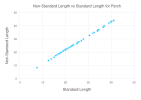

In [75]:
# Illustrez la :NonStandardLength en fonction de la :StandardLength
p_vif = plot(x=perche.StandardLength, y=perche.NonStandardLength, Geom.point,
    Guide.xlabel("Standard Length"),
    Guide.ylabel("Non-Standard Length"),
    Guide.title("Non-Standard Length vs Standard Length for Perch"))


## c) Sélection d'un sous-ensemble des variables explicatives 

Sélectionnez un sous-ensemble des variables explicatives pour lequel il n'y a pas de multicolinéarité.

Toutes les variables explicatives sont toutes liées linéairement entre elles. Pour éviter la multicolinéarité, il faut choisir une seule variable.

In [77]:
# Sélectionnez un sous-ensemble des variables explicatives pour lequel il n'y a pas de multicolinéarité.
perche_subset = perche[:, [:StandardLength, :Height, :Width]]


Row,StandardLength,Height,Width
,Float64,Float64,Float64
1,7.5,2.1,1.4
2,12.5,3.5,2.0
3,13.8,3.8,2.4
4,15.0,4.6,2.6
5,15.7,4.6,2.9
6,16.2,5.2,3.3
7,16.8,5.2,3.1
8,17.2,5.6,3.1
9,17.8,5.1,3.0


## c)  Identification du meilleur modèle de régression linéaire simple

Puisqu'il y a présence de multicolinéarité entre toutes les variables, on cherche le meilleur modèle unidimensionnel. Utilisez le critère de votre choix pour l'identifier.

**Suggestion :** Vous pouvez transformer la variable d'intérêt pour trouver le meilleur modèle linéaire unidimensionnel.

In [ ]:
# ## c)  Identification du meilleur modèle de régression linéaire simple

#Puisqu'il y a présence de multicolinéarité entre toutes les variables, on cherche le meilleur modèle unidimensionnel. Utilisez le critère de votre choix pour l'identifier.

# **Suggestion :** Vous pouvez transformer la variable d'intérêt pour trouver le meilleur modèle linéaire unidimensionnel.

best_model = LinearRegression().fit(X_transformed, y)

LoadError: UndefVarError: `LinearRegression` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## d) Vérification des hypothèses de la régression

Vérifiez si les hypothèses 1 à 4 de la régression sont satisfaites. Pour ce faire, tracer les graphiques suivants :
- le nuage des points {(ŷᵢ, eᵢ) : 1 ≤ i ≤ n} pour vérifier les hypothèses 1 et 2
- la droite de Henry pour vérifier l'hypothèse 4.

**Suggestion :** Vous pouvez utiliser la fonction `henryplot()` fournie pour tracer le diagramme quantile-quantile entre la loi normale et les résidus.


In [ ]:
function henryplot(y::Vector{<:Real})

    n = length(y)
    ysorted = sort(y)

    p = ( collect(1:n) .- .5 ) /n

    fd = fit(Normal,y)

    q = quantile.(fd,p)

    plot(x=ysorted, y=q, Geom.point,
    Guide.xlabel("Empirical quantiles"), Guide.ylabel("Estimated quantiles"),
    Theme(discrete_highlight_color=c->nothing),
    Geom.abline(color="red"))

end

## e) Relation pour les poids originaux

Tracez le nuage de points illustrant les poids originaux des perches (dans le cas où vous auriez fait une transformation) en fonction votre variable explicative ainsi que la relation obtenue.

**Suggestion :** Utilisez la fonction `layer()` pour superposer plusieurs couches sur un graphique.

# Exercice 4 : Recherche du meilleur modèle possible

Dans cet exercice, on cherche le meilleur modèle pour prédire le poids de perches. J'ai l'impression que les modèles suivants pourraient être pertinents :
- X = StandardLength * Width * Height (on suppose que le poisson est de la forme d'un prisme rectangulaire)
- X = StandardLength * Width^2 (on suppose que le poisson est un cylindre)
- etc.

C'est votre travail de créer de nouvelles variables explicatives à partir de celle que vous avez pour rechercher le meilleur modèle possible.